In [185]:
# importing necessary libries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for supress warning
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# to build ann model and check score
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


In [186]:
data=pd.read_excel('Uttar_Pradesh_Dataset 2.xlsx')
df=data.copy()

In [187]:
# checking top 5 rows
df.head(5)

,Unnamed: 0,Type_of_plot,City,Total Price,Unit,Rupee_per_area,Open_Date,Description,Area,Apartement,Project Name
0,0,2 BHK Apartment,Ghaziabad,57.25 L,L,"5,000 / sq ft",Possession by Nov 2022,2 BHK in Ahinsa Khand 2 Ghaziabad:It has an a...,1145,2 BHK Apartment,Aegis Trine Towers
1,1,3 BHK Apartment,Ghaziabad,2.06 Cr,Cr,"8,300 / sq ft",Possession by Jul 2024,3 BHK in Kinauni Village Ghaziabad:Itâs a 3...,2485,3 BHK Apartment,Rio Heights Apex D Rio
2,2,2 BHK Apartment,Greater Noida,53.12 L,L,"4,660 / sq ft",Possession by May 2024,2 BHK in Techzone 4 Greater Noida:It has a sa...,1140,2 BHK Apartment,Dev Sai Sports Home Phase 2
3,3,2 BHK Apartment,Greater Noida,47.31 L,L,"3,850 / sq ft",Possession by Feb 2026,2 BHK in Sector 16B Noida Extension Greater N...,1229,2 BHK Apartment,RG Luxury Homes
4,4,3 BHK Apartment,Greater Noida,78.75 L,L,"4,716 / sq ft",Possession by Oct 2024,3 BHK in ETA 2 Greater Noida:It has an area o...,1670,3 BHK Apartment,SKA Metro Ville


In [188]:
# checking shape of data
df.shape

(102100, 11)

- there are 102100 rows and 10 columns.

In [189]:
# checking unique value in data
for i in df.columns:
    print(df[i].unique())
    print('*' * 20)


[     0      1      2 ... 102097 102098 102099]
********************
['2 BHK Apartment' '3 BHK Apartment' 'Residential Plot' '1 BHK Apartment'
 '2 BHK Independent House' '2 BHK Villa' '4 BHK Apartment' '1 BHK Villa']
********************
['Ghaziabad' 'Greater Noida' 'Lucknow' 'Noida']
********************
[' 57.25 L' ' 2.06 Cr' ' 53.12 L' ' 47.31 L' ' 78.75 L' ' 25 L' ' 71.89 L'
 ' 17.03 L' ' 28.8 L' ' 98 L' ' 46 L' ' 51.89 L' ' 78.72 L' ' 67.7 L'
 ' 76.21 L' ' 29.9 L' ' 37.39 L' ' 3.87 Cr' ' 24.32 L' ' 49 L']
********************
[' L' ' Cr']
********************
['5,000 / sq ft' '8,300 / sq ft' '4,660 / sq ft' '3,850 / sq ft'
 '4,716 / sq ft' '2,777 / sq ft' '4,424 / sq ft' '4,518 / sq ft'
 '2,400 / sq ft' '4,900 / sq ft' '3,680 / sq ft' '4,850 / sq ft'
 '4,700 / sq ft' '4,299 / sq ft' '5,293 / sq ft' '2,990 / sq ft'
 '3,800 / sq ft' '11,000 / sq ft' '4,000 / sq ft']
********************
['Possession by Nov 2022' 'Possession by Jul 2024'
 'Possession by May 2024' 'Possession by Feb 2

In [190]:
df.columns

Index(['Unnamed: 0', 'Type_of_plot', 'City', 'Total Price', 'Unit',
       'Rupee_per_area', 'Open_Date', 'Description', 'Area', 'Apartement',
       'Project Name'],
      dtype='object')

In [191]:
df.Type_of_plot.unique()

array(['2 BHK Apartment', '3 BHK Apartment', 'Residential Plot',
       '1 BHK Apartment', '2 BHK Independent House', '2 BHK Villa',
       '4 BHK Apartment', '1 BHK Villa'], dtype=object)

In [192]:
df.Apartement.unique()

array(['2 BHK Apartment', '3 BHK Apartment', 'Residential Plot',
       '1 BHK Apartment', '2 BHK Independent House', '2 BHK Villa',
       '4 BHK Apartment', '1 BHK Villa'], dtype=object)

- appartment and type of plot has same data so i will remove one of them.
- i will remove unnamed feature as well because i dont need sr. no. feature.

In [193]:
df=df.drop(['Unnamed: 0','Type_of_plot'],axis=1)
df.head()

,City,Total Price,Unit,Rupee_per_area,Open_Date,Description,Area,Apartement,Project Name
0,Ghaziabad,57.25 L,L,"5,000 / sq ft",Possession by Nov 2022,2 BHK in Ahinsa Khand 2 Ghaziabad:It has an a...,1145,2 BHK Apartment,Aegis Trine Towers
1,Ghaziabad,2.06 Cr,Cr,"8,300 / sq ft",Possession by Jul 2024,3 BHK in Kinauni Village Ghaziabad:Itâs a 3...,2485,3 BHK Apartment,Rio Heights Apex D Rio
2,Greater Noida,53.12 L,L,"4,660 / sq ft",Possession by May 2024,2 BHK in Techzone 4 Greater Noida:It has a sa...,1140,2 BHK Apartment,Dev Sai Sports Home Phase 2
3,Greater Noida,47.31 L,L,"3,850 / sq ft",Possession by Feb 2026,2 BHK in Sector 16B Noida Extension Greater N...,1229,2 BHK Apartment,RG Luxury Homes
4,Greater Noida,78.75 L,L,"4,716 / sq ft",Possession by Oct 2024,3 BHK in ETA 2 Greater Noida:It has an area o...,1670,3 BHK Apartment,SKA Metro Ville


- total price has seprate unit feature so we will remove string from total price.
- in rupees_per_area feature we will remove sq ft and rename as rupee_per_area sq ft.
- we will modify date feature as well.

In [194]:
# Extract only digits
df['Total Price'] = df['Total Price'].str.extract('(\d+)', expand=True)
df['Total Price'] = df['Total Price'].astype(float)

In [195]:
df = df.rename(columns={'Rupee_per_area': 'rupee_per_area-sq_ft'})

In [196]:
df['rupee_per_area-sq_ft'] = df['rupee_per_area-sq_ft'].str.replace(r'[^\d,]', '', regex=True)
df['rupee_per_area-sq_ft'] = df['rupee_per_area-sq_ft'].str.replace(',', '').astype(float)

In [197]:
df["Year"] = df['Open_Date'].str.extract('(\d+)', expand=True)
df['Year'] = df['Year'].astype(int)


In [198]:
df=df.drop(['Open_Date'],axis=1)

In [199]:
df['Year'] = df['Year'].replace({2023: 2, 2025: 0, 2024: 1, 2022: 3, 2026: -1})

In [200]:
df

,City,Total Price,Unit,rupee_per_area-sq_ft,Description,Area,Apartement,Project Name,Year
0,Ghaziabad,57.0,L,5000.0,2 BHK in Ahinsa Khand 2 Ghaziabad:It has an a...,1145,2 BHK Apartment,Aegis Trine Towers,3
1,Ghaziabad,2.0,Cr,8300.0,3 BHK in Kinauni Village Ghaziabad:Itâs a 3...,2485,3 BHK Apartment,Rio Heights Apex D Rio,1
2,Greater Noida,53.0,L,4660.0,2 BHK in Techzone 4 Greater Noida:It has a sa...,1140,2 BHK Apartment,Dev Sai Sports Home Phase 2,1
3,Greater Noida,47.0,L,3850.0,2 BHK in Sector 16B Noida Extension Greater N...,1229,2 BHK Apartment,RG Luxury Homes,-1
4,Greater Noida,78.0,L,4716.0,3 BHK in ETA 2 Greater Noida:It has an area o...,1670,3 BHK Apartment,SKA Metro Ville,1
...,...,...,...,...,...,...,...,...,...
102095,Lucknow,29.0,L,2990.0,2 BHK in Mohanlalganj Lucknow:This spacious 2...,1000,2 BHK Villa,Kalpana Residency,3
102096,Greater Noida,37.0,L,3800.0,2 BHK in CHI 5 Greater Noida:Itâs a 2 bhk m...,984,2 BHK Apartment,Nimbus Express Park View 2,3
102097,Noida,3.0,Cr,11000.0,4 BHK in Sector 78 Noida:Well designed 4 bhk ...,3525,4 BHK Apartment,Mahagun Mezzaria,2
102098,Lucknow,24.0,L,3800.0,1 BHK in Jankipuram Extension Lucknow:Itâs ...,640,1 BHK Villa,Vasundhara R S Homes,0


In [201]:
# checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102100 entries, 0 to 102099
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   City                  102100 non-null  object 
 1   Total Price           102100 non-null  float64
 2   Unit                  102100 non-null  object 
 3   rupee_per_area-sq_ft  102100 non-null  float64
 4   Description           102100 non-null  object 
 5   Area                  102100 non-null  int64  
 6   Apartement            102100 non-null  object 
 7   Project Name          102100 non-null  object 
 8   Year                  102100 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 7.0+ MB


## EDA

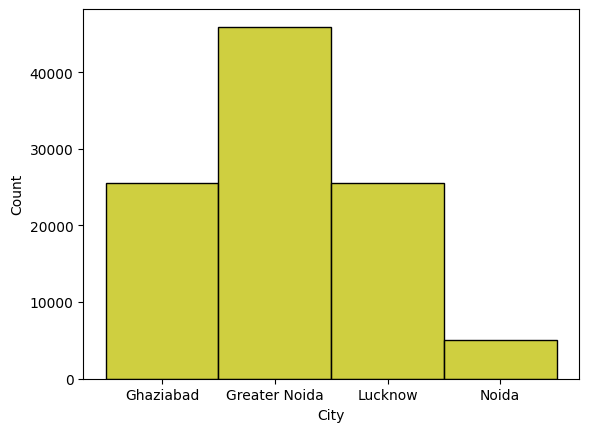

In [202]:
# checking City on histplot
sns.histplot(df['City'],color="y");

- greater noida has most of the room.
  

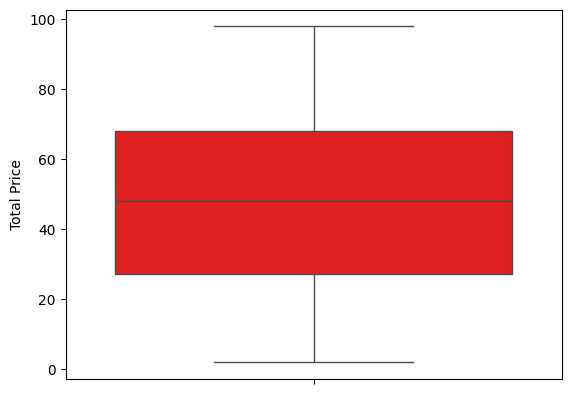

In [203]:
# checking total price with boxplot
sns.boxplot(df['Total Price'],color='red');

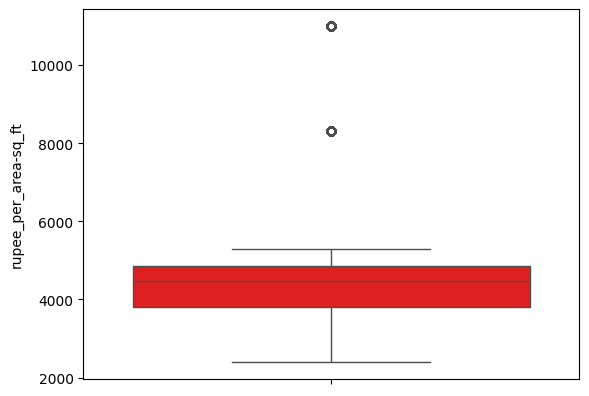

In [204]:
sns.boxplot(df['rupee_per_area-sq_ft'],color='red');

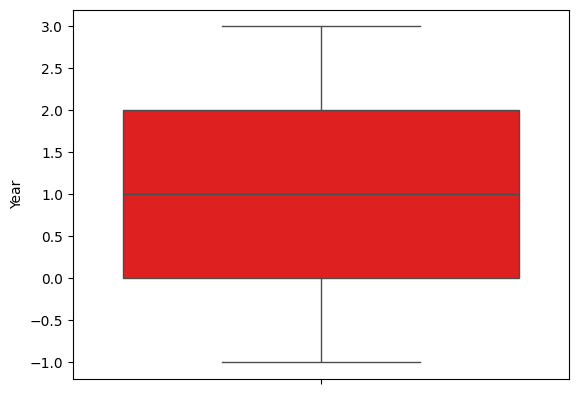

In [205]:
sns.boxplot(df['Year'],color='red');

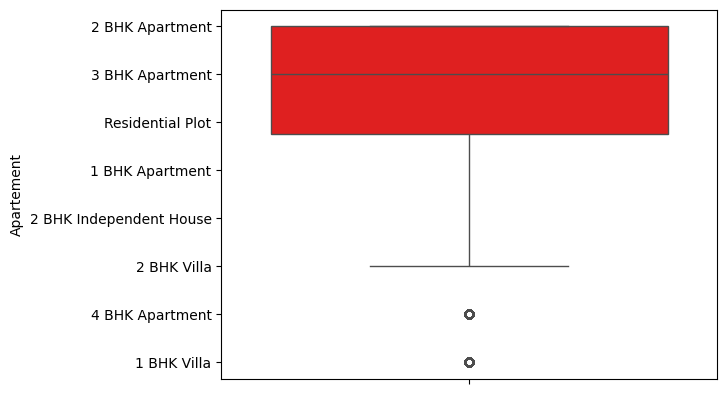

In [206]:
sns.boxplot(df['Apartement'],color='red');

In [207]:
# checking missing values
df.isnull().sum()

,0
City,0
Total Price,0
Unit,0
rupee_per_area-sq_ft,0
Description,0
Area,0
Apartement,0
Project Name,0
Year,0


<Axes: >

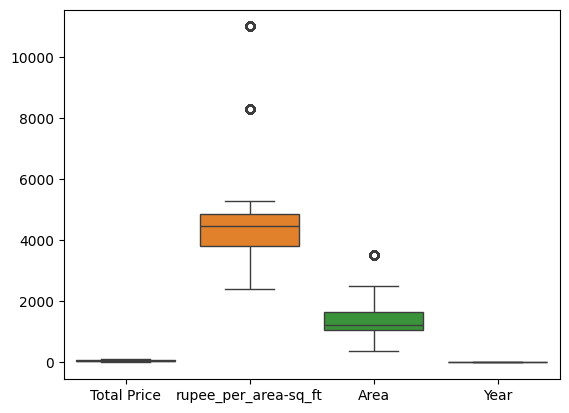

In [208]:
# checking outlier
sns.boxplot(df)

- there are few outlier present in data.
- assuming all data point are real.

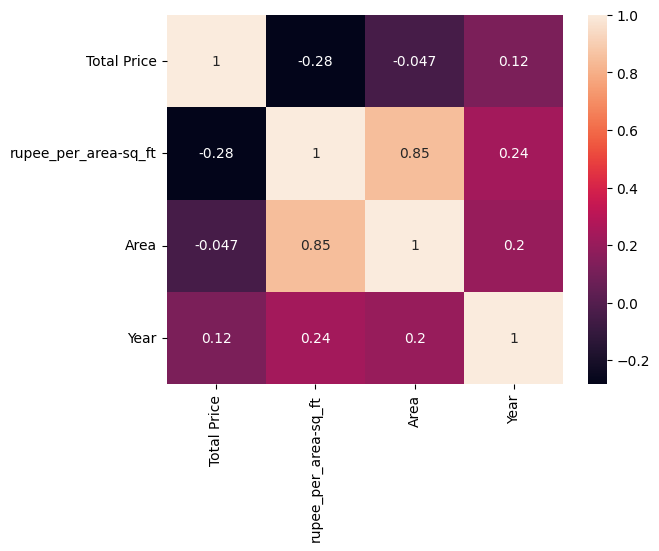

In [209]:
# checking correleation in data
numcol=df.select_dtypes(include=np.number).columns
sns.heatmap(df[numcol].corr(),annot=True);

- there are no strong correleation in data.

In [210]:
df=df.drop('Description',axis=1)

In [211]:
# lets convert to numeric feature use label encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df=df.apply(le.fit_transform)


In [212]:
# lets scale data for ann
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df=sc.fit_transform(df)

In [213]:
# lets seprate independent and dependent feature
X=df[:,:-1]
y=df[:,-1]

In [214]:
X.shape,y.shape

((102100, 7), (102100,))

In [215]:
# lets seprate data into train and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [216]:
# checking shape of X_train,y_train,X_test,y_test
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((81680, 7), (81680,), (20420, 7), (20420,))

In [217]:
model=Sequential()

In [218]:
model.add(Dense(128,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='linear'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [219]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)


In [220]:
model.fit(X_train,y_train,epochs=100,batch_size=32)

Epoch 1/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0592 - mean_squared_error: 0.0592
Epoch 2/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.3656e-04 - mean_squared_error: 1.3656e-04
Epoch 3/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 2.3586e-04 - mean_squared_error: 2.3586e-04
Epoch 4/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.4305e-04 - mean_squared_error: 1.4305e-04
Epoch 5/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.1930e-04 - mean_squared_error: 1.1930e-04
Epoch 6/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1.2408e-04 - mean_squared_error: 1.2408e-04
Epoch 7/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2.1982e-04 - mean_squared_error: 2.1982e-04
Epoch 8/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 5.8119e-05 - mean_squared_error: 5.8119e-05
Epoch 9/100
2553/2553 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.2602e-04 - mean_squared_error: 1.2602e-04
Epoch 10/100
2553/2553 ━━━━━━━━━━━━━━━━━━

In [221]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,181 (133.52 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,788 (89.02 KB)

In [222]:
# check r2,rmse,mae,mse on train set ,test set

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Make predictions on the training set
y_train_pred = model.predict(X_train)

# Calculate R2, RMSE, MAE, and MSE for the training set
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

# Print the results for the training set
print("Training Set Metrics:")
print("R2:", r2_train)
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("MSE:", mse_train)

# Make predictions on the test set
y_test_pred = model.predict(X_test)

# Calculate R2, RMSE, MAE, and MSE for the test set
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Print the results for the test set
print("\nTest Set Metrics:")
print("R2:", r2_test)
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("MSE:", mse_test)


2553/2553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Training Set Metrics:
R2: 0.999999289072648
RMSE: 0.0008429677794314966
MAE: 0.0006370435529504181
MSE: 7.105946771596682e-07
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Test Set Metrics:
R2: 0.9999992871890194
RMSE: 0.0008450612388534191
MAE: 0.0006352548730722761
MSE: 7.141284974124754e-07


- we are getting good r2 in train and test set is around 100%
- rmse,mae is around score is around 0.

In [232]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
# Assuming df is your DataFrame and 'categorical_feature' is the name of your categorical column
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

# Create transformers for categorical and numerical features
categorical_transformer = Pipeline(steps=[
    ('label_encoder', ColumnTransformer(
        transformers=[('encoder', LabelEncoder(), categorical_features)],
        remainder='passthrough'  # Keep numerical features unchanged
    ))
])


numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
    ])

# Create the final pipeline with the preprocessor and the model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Sequential([
        Dense(128, activation='relu', input_dim=X_train.shape[1]),  # Adjust input_dim if necessary
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ]))
])


# Compile the model within the pipeline
pipeline.named_steps['model'].compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)
pipeline.fit(X_train, y_train)


# Make predictions on the training and test sets using the pipeline
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [179]:
#  saving .pkl file to computer

import pickle

# Assuming your model is named 'pipeline'
with open('my_model.pkl', 'wb') as f:
  pickle.dump(pipeline, f)

files.download('my_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>